In [1]:
import json

# Load train and dev data
with open('train.json', 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open('dev.json', 'r', encoding='utf-8') as f:
    dev_data = json.load(f)

print("Train samples:", len(train_data))
print("Dev/Test samples:", len(dev_data))

Train samples: 3068
Dev/Test samples: 500


In [2]:
import nltk
import torch
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
import pickle

nltk.download('punkt')
nltk.download('punkt_tab') # Download the punkt_tab data

# Load evidence from train data
def extract_evidence_strings(data):
    evidence_list = []
    for entry in data:
        for q in entry.get("questions", []):
            for ans in q.get("answers", []):
                evidence_list.append(f"{q['question']} {ans.get('answer', '')}")
    return evidence_list

evidence_texts = extract_evidence_strings(train_data)
evidence_texts += extract_evidence_strings(dev_data)

# BM25 Setup
tokenized_corpus = [nltk.word_tokenize(doc.lower()) for doc in evidence_texts]
bm25 = BM25Okapi(tokenized_corpus)

# DPR Setup
dpr_model = SentenceTransformer('facebook-dpr-question_encoder-single-nq-base')
evidence_embeddings = dpr_model.encode(evidence_texts, convert_to_tensor=True, show_progress_bar=True)
# with open('evidence_embeddings.pkl', 'rb') as f:
#     evidence_embeddings = pickle.load(f)

with open('evidence_embeddings2.pkl', 'wb') as f:
    pickle.dump(evidence_embeddings, f)

    
# Function to retrieve top-k evidences
def retrieve_evidence_bm25_dpr(claim_text, top_k=5):
    bm25_scores = bm25.get_scores(nltk.word_tokenize(claim_text.lower()))
    top_bm25_idxs = sorted(range(len(bm25_scores)), key=lambda i: bm25_scores[i], reverse=True)[:50]
    candidate_texts = [evidence_texts[i] for i in top_bm25_idxs]
    candidate_embeddings = evidence_embeddings[top_bm25_idxs]

    claim_embedding = dpr_model.encode(claim_text, convert_to_tensor=True)
    cos_scores = util.pytorch_cos_sim(claim_embedding, candidate_embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k)

    return [candidate_texts[i] for i in top_results.indices]

# Example usage
for i in range(2):
    print(f"\nClaim: {dev_data[i]['claim']}")
    evidences = retrieve_evidence_bm25_dpr(dev_data[i]['claim'])
    for ev in evidences:
        print("  -", ev)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hasan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hasan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Batches:   0%|          | 0/309 [00:00<?, ?it/s]


Claim: In a letter to Steve Jobs, Sean Connery refused to appear in an apple commercial.
  - Did comedian Steve Harvey write a post titled "How I Feel About Trump"  ? No, that's not true: The post is a letter written in 2016 and addressed to the Republican National Committee by someone who claims to be an 80-year-old who is responding to a fundraiser solicitation.
  - Which staff member in Tony Evers' office recorded a May 14 2020 phone meeting between the governor and Republican legislative leaders? Tony Evers has refused to identify the staff member
  - Was there anything controversial about any campaign letters sent out by Senator Ted Cruz in 2018? Ted Cruz’s Senate re-election campaign has been sending voters in Texas a fund-raising letter in an envelope labeled “summons enclosed,” drawing criticism from some who called it misleading and raising questions about whether such a practice was legal.

Confusion arises not just from the letter itself but from the envelope it arrives in.

In [3]:
from transformers import AutoTokenizer
import pandas as pd

# Prepare training data with claim + top 3 evidence
def prepare_bert_data(data, evidence_texts, top_k=3):
    inputs, labels = [], []
    for entry in tqdm(data):
        claim = entry['claim']
        label = entry['label']

        # Get top-k evidence for this claim
        top_evi = retrieve_evidence_bm25_dpr(claim, top_k=top_k)
        combined_evidence = " ".join(top_evi)

        # Input: [claim] + [retrieved evidence]
        input_text = f"Claim: {claim} Evidence: {combined_evidence}"
        inputs.append(input_text)
        labels.append(label)

    return pd.DataFrame({"text": inputs, "label": labels})

with open('augmented_train2.json', 'r', encoding='utf-8') as f:
    combined_data = json.load(f)

# Prepare train and test data
combined_df = prepare_bert_data(combined_data, evidence_texts)  # use subset for speed
test_df = prepare_bert_data(dev_data, evidence_texts)
combined_df.head()


100%|██████████| 500/500 [00:25<00:00, 19.27it/s]


,text,label
0,Claim: Not a single bulletproof jacket was pro...,Supported
1,"Claim: In 2017, South Africa recorded an inflo...",Supported
2,Claim: The Medicare for All bill would trim th...,Not Enough Evidence
3,Claim: Trump-Owned Property In Agrabah Burned ...,Refuted
4,Claim: Amy Klobuchar has won Michele Bachmann'...,Supported


In [4]:
label2id = {
    "Supported": 0,
    "Refuted": 1,
    "Not Enough Evidence": 2,
    "Conflicting Evidence/Cherrypicking": 3
}
id2label = {v: k for k, v in label2id.items()}

combined_df['label_id'] = combined_df['label'].map(label2id)
test_df['label_id'] = test_df['label'].map(label2id)

combined_df['label_id'].value_counts()

label_id
3    885
1    871
0    849
2    846
Name: count, dtype: int64

In [5]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from transformers import AutoTokenizer

# Tokenize
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

# Rename column for Trainer compatibility
combined_df = combined_df.rename(columns={"label_id": "labels"})
combined_df = combined_df.sample(n=1000, random_state=42).reset_index(drop=True) # Using the subset

test_df = test_df.rename(columns={"label_id": "labels"})

# Then convert to Huggingface Dataset and tokenize
train_dataset = Dataset.from_pandas(combined_df[["text", "labels"]]).map(tokenize_function, batched=True)
test_dataset = Dataset.from_pandas(test_df[["text", "labels"]]).map(tokenize_function, batched=True)
print(len(train_dataset))

# Define model
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)

# Training setup
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=20,
    logging_dir="./logs",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

# Train!
trainer.train()

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

1000


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/2500 [00:00<?, ?it/s]

...

  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 3.800785779953003, 'eval_runtime': 9.2103, 'eval_samples_per_second': 54.287, 'eval_steps_per_second': 6.84, 'epoch': 19.0}
{'loss': 0.0002, 'grad_norm': 0.003253557486459613, 'learning_rate': 0.0, 'epoch': 20.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 3.803964138031006, 'eval_runtime': 8.3091, 'eval_samples_per_second': 60.175, 'eval_steps_per_second': 7.582, 'epoch': 20.0}
{'train_runtime': 1360.185, 'train_samples_per_second': 14.704, 'train_steps_per_second': 1.838, 'train_loss': 0.28164228137135505, 'epoch': 20.0}


TrainOutput(global_step=2500, training_loss=0.28164228137135505, metrics={'train_runtime': 1360.185, 'train_samples_per_second': 14.704, 'train_steps_per_second': 1.838, 'total_flos': 5262315601920000.0, 'train_loss': 0.28164228137135505, 'epoch': 20.0})

In [6]:
preds = trainer.predict(test_dataset)
pred_labels = preds.predictions.argmax(axis=1)

# Attach predictions for eval
test_df['pred_label'] = [id2label[i] for i in pred_labels]
test_df[['text', 'label', 'pred_label']].head()

  0%|          | 0/63 [00:00<?, ?it/s]

,text,label,pred_label
0,"Claim: In a letter to Steve Jobs, Sean Connery...",Refuted,Refuted
1,Claim: Trump Administration claimed songwriter...,Refuted,Conflicting Evidence/Cherrypicking
2,Claim: Due to Imran Khan's criticism of Macron...,Refuted,Conflicting Evidence/Cherrypicking
3,Claim: UNESCO declared Nadar community as the ...,Refuted,Refuted
4,Claim: Republican Matt Gaetz was part of a com...,Refuted,Conflicting Evidence/Cherrypicking


🔍 Classification Report:

                                    precision    recall  f1-score   support

                         Supported       0.47      0.16      0.23       122
                           Refuted       0.71      0.53      0.61       305
               Not Enough Evidence       0.00      0.00      0.00        35
Conflicting Evidence/Cherrypicking       0.10      0.61      0.17        38

                          accuracy                           0.41       500
                         macro avg       0.32      0.32      0.26       500
                      weighted avg       0.56      0.41      0.44       500

✅ Accuracy: 0.4100


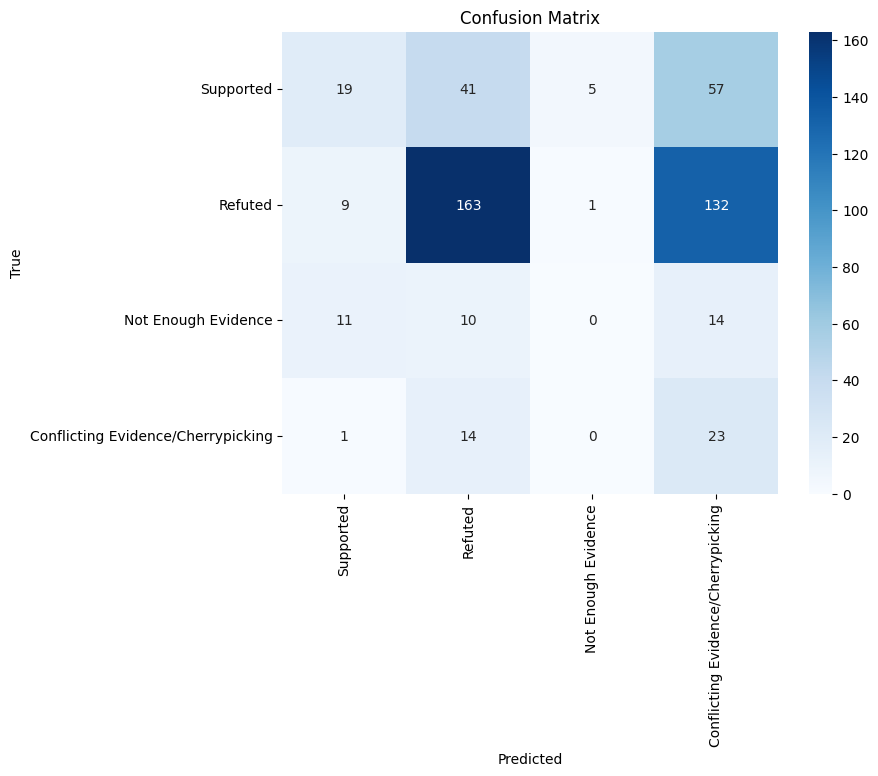

In [7]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# True vs Predicted
true_labels = test_df['labels']
pred_labels = preds.predictions.argmax(axis=1)

# Classification report
print("🔍 Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=label2id.keys()))

# Accuracy
acc = accuracy_score(true_labels, pred_labels)
print(f"✅ Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label2id.keys(), yticklabels=label2id.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()